## Moving Average

In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns']]
fin_data

,date,weighted_sector_returns
0,2017-01-03,0.000000
1,2017-01-04,0.353432
2,2017-01-05,-0.182223
3,2017-01-06,1.397196
4,2017-01-09,3.645896
...,...,...
2258,2026-07-13,-0.746327
2259,2026-07-14,0.906947
2260,2026-07-15,0.779799
2261,2026-07-16,1.505893


In [3]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 35.5 KB


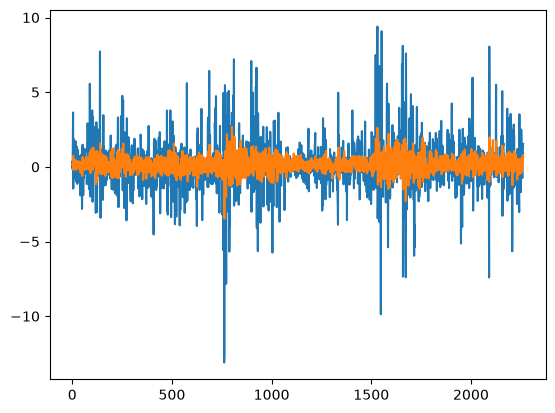

0.09438673784118468


In [9]:
# Fitting the MA model and plotting the forecast

from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Forecast the first MA(1) model
mod = ARIMA(fin_data['weighted_sector_returns'], order=(0,0,100))
res = mod.fit()

orig_data = fin_data['weighted_sector_returns']
pred = res.predict()

plt.plot(orig_data)
plt.plot(pred)
plt.show()
print(r2_score(orig_data, pred))

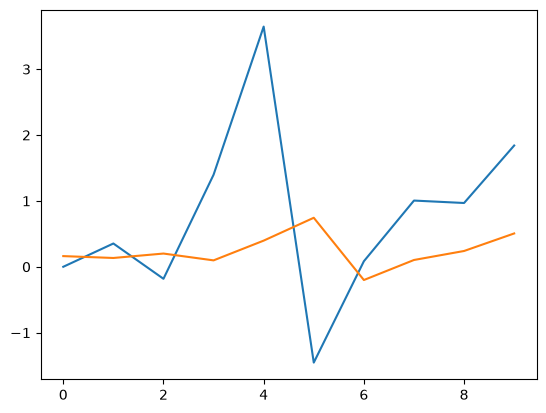

In [10]:
## Lets take a closer look
plt.plot(orig_data[:10])
plt.plot(pred[:10])
plt.show()

Its not capturing enough of the variation. There is no need moving forward. Lets head straight to ARMA.